<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana_12_Metricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métricas de Evaluación para Clasificación: Binaria y Multiclase

## Usando el Clasificador del Vecino Más Cercano (KNN)

En este notebook aprenderemos:
1. Métricas de evaluación para clasificación binaria
2. Métricas de evaluación para clasificación multiclase
3. Implementación práctica con KNN
4. Interpretación de resultados

##**Instalación** e importación de librerías

In [ ]:
# Instalación e importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


---
## PARTE 1: CLASIFICACIÓN BINARIA - Hold-Out
---

In [ ]:
print("="*70)
print("CLASIFICACIÓN BINARIA - Detección de Cáncer de Mama")
print("="*70)

# Cargar dataset de cáncer de mama (problema binario)
data_cancer = load_breast_cancer()
X_binary = data_cancer.data
y_binary = data_cancer.target

print(f"\nDimensión de los datos: {X_binary.shape}")
print(f"Clases: {data_cancer.target_names}")
print(f"Distribución de clases:")
print(pd.Series(y_binary).value_counts())

# Dividir datos
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# Entrenar modelo KNN
knn_binary = KNeighborsClassifier(n_neighbors=5)
knn_binary.fit(X_train_bin, y_train_bin)

# Predicciones
y_pred_bin = knn_binary.predict(X_test_bin)
y_pred_proba_bin = knn_binary.predict_proba(X_test_bin)[:, 1]

CLASIFICACIÓN BINARIA - Detección de Cáncer de Mama

Dimensión de los datos: (569, 30)
Clases: ['malignant' 'benign']
Distribución de clases:
1    357
0    212
Name: count, dtype: int64


### 1.1 Matriz de Confusión
La matriz de confusión muestra los Verdaderos Positivos (TP), Verdaderos Negativos (TN),
Falsos Positivos (FP) y Falsos Negativos (FN)

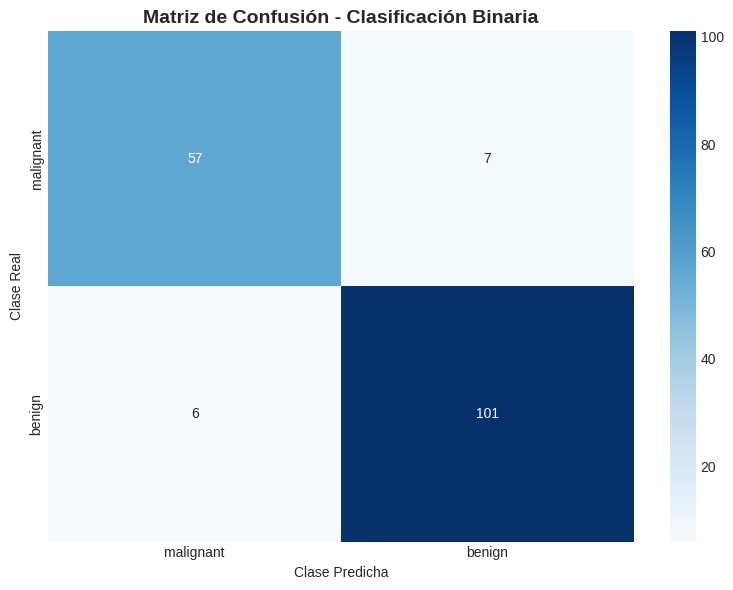

In [ ]:
cm_binary = confusion_matrix(y_test_bin, y_pred_bin)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=data_cancer.target_names,
            yticklabels=data_cancer.target_names)
plt.title('Matriz de Confusión - Clasificación Binaria', fontsize=14, fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

###Extraer componentes de la matriz de confusión

In [ ]:
tn, fp, fn, tp = cm_binary.ravel()
print(f"\nComponentes de la Matriz de Confusión:")
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")


Componentes de la Matriz de Confusión:
Verdaderos Negativos (TN): 57
Falsos Positivos (FP): 7
Falsos Negativos (FN): 6
Verdaderos Positivos (TP): 101


### 1.2 Métricas Principales

**Accuracy (Exactitud)**: Proporción de predicciones correctas
- Fórmula: (TP + TN) / (TP + TN + FP + FN)

**Precision (Precisión)**: De los casos predichos como positivos, ¿cuántos son realmente positivos?
- Fórmula: TP / (TP + FP)

**Recall (Sensibilidad/Exhaustividad)**: De todos los casos positivos reales, ¿cuántos detectamos?
- Fórmula: TP / (TP + FN)

**F1-Score**: Media armónica de Precision y Recall
- Fórmula: 2 * (Precision * Recall) / (Precision + Recall)

In [ ]:
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin)
recall = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

print("\n" + "="*70)
print("MÉTRICAS DE EVALUACIÓN - CLASIFICACIÓN BINARIA")
print("="*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Reporte de clasificación completo
print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN COMPLETO")
print("="*70)
print(classification_report(y_test_bin, y_pred_bin, target_names=data_cancer.target_names))


MÉTRICAS DE EVALUACIÓN - CLASIFICACIÓN BINARIA
Accuracy:  0.9240 (92.40%)
Precision: 0.9352 (93.52%)
Recall:    0.9439 (94.39%)
F1-Score:  0.9395 (93.95%)

REPORTE DE CLASIFICACIÓN COMPLETO
              precision    recall  f1-score   support

   malignant       0.90      0.89      0.90        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



---
## PARTE 2: CLASIFICACIÓN BINARIA - Stratified K-Fold Cross Validation
---

Resultados 5-Fold (media ± desviación):
Accuracy : 0.963 ± 0.018
Precision: 0.957 ± 0.026
Recall   : 0.986 ± 0.012
F1       : 0.971 ± 0.014
ROC AUC  : 0.985 ± 0.013
Brier    : 0.031 ± 0.012


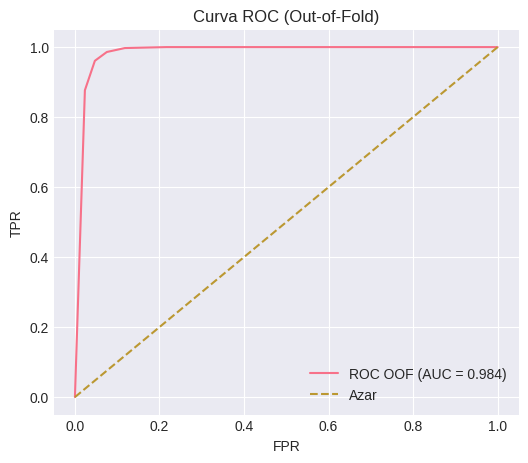

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, brier_score_loss
)

# 1) Datos de ejemplo (binario)
X, y = load_breast_cancer(return_X_y=True)
# Ejemplo para tus datos:
# import pandas as pd
# df = pd.read_csv('/content/tus_datos.csv')
# X = df[['col1','col2', 'col3']].values
# y = (df['target'] == 'positivo').astype(int).values

# 2) Configuración
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k = 5  # vecinos

metrics = {"acc": [], "prec": [], "rec": [], "f1": [], "auc": [], "brier": []}
oof_proba = np.zeros(len(y))  # probabilidades out-of-fold

# 3) K-Fold manual
for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_va = X[tr_idx], X[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    # Escalado SIN pipeline (evitar fuga: fit solo en train)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)

    # Modelo
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr, y_tr)

    # Predicciones
    proba_va = knn.predict_proba(X_va)[:, 1]
    pred_va = (proba_va >= 0.5).astype(int)

    # Guardar OOF
    oof_proba[va_idx] = proba_va

    # Métricas por fold
    metrics["acc"].append(accuracy_score(y_va, pred_va))
    metrics["prec"].append(precision_score(y_va, pred_va, zero_division=0))
    metrics["rec"].append(recall_score(y_va, pred_va))
    metrics["f1"].append(f1_score(y_va, pred_va))
    metrics["auc"].append(roc_auc_score(y_va, proba_va))
    metrics["brier"].append(brier_score_loss(y_va, proba_va))

# 4) Resumen
m = lambda a: f"{np.mean(a):.3f} ± {np.std(a):.3f}"
print("Resultados 5-Fold (media ± desviación):")
print(f"Accuracy : {m(metrics['acc'])}")
print(f"Precision: {m(metrics['prec'])}")
print(f"Recall   : {m(metrics['rec'])}")
print(f"F1       : {m(metrics['f1'])}")
print(f"ROC AUC  : {m(metrics['auc'])}")
print(f"Brier    : {m(metrics['brier'])}")

# 5) ROC OOF
fpr, tpr, _ = roc_curve(y, oof_proba)
auc_oof = roc_auc_score(y, oof_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC OOF (AUC = {auc_oof:.3f})')
plt.plot([0,1],[0,1],'--', label='Azar')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC (Out-of-Fold)')
plt.legend(); plt.grid(True); plt.show()


---
# PARTE 3: CLASIFICACIÓN MULTICLASE
---

In [ ]:
print("\n\n" + "="*70)
print("CLASIFICACIÓN MULTICLASE - Dataset Iris (3 clases)")
print("="*70)

# Cargar dataset Iris (problema multiclase)
iris = load_iris()
X_multi = iris.data
y_multi = iris.target

print(f"\nDimensión de los datos: {X_multi.shape}")
print(f"Clases: {iris.target_names}")
print(f"Distribución de clases:")
print(pd.Series(y_multi).value_counts())

# Dividir datos
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)

# Entrenar modelo KNN
knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_multi, y_train_multi)

# Predicciones
y_pred_multi = knn_multi.predict(X_test_multi)
y_pred_proba_multi = knn_multi.predict_proba(X_test_multi)



CLASIFICACIÓN MULTICLASE - Dataset Iris (3 clases)

Dimensión de los datos: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Distribución de clases:
0    50
1    50
2    50
Name: count, dtype: int64


### 2.1 Matriz de Confusión Multiclase

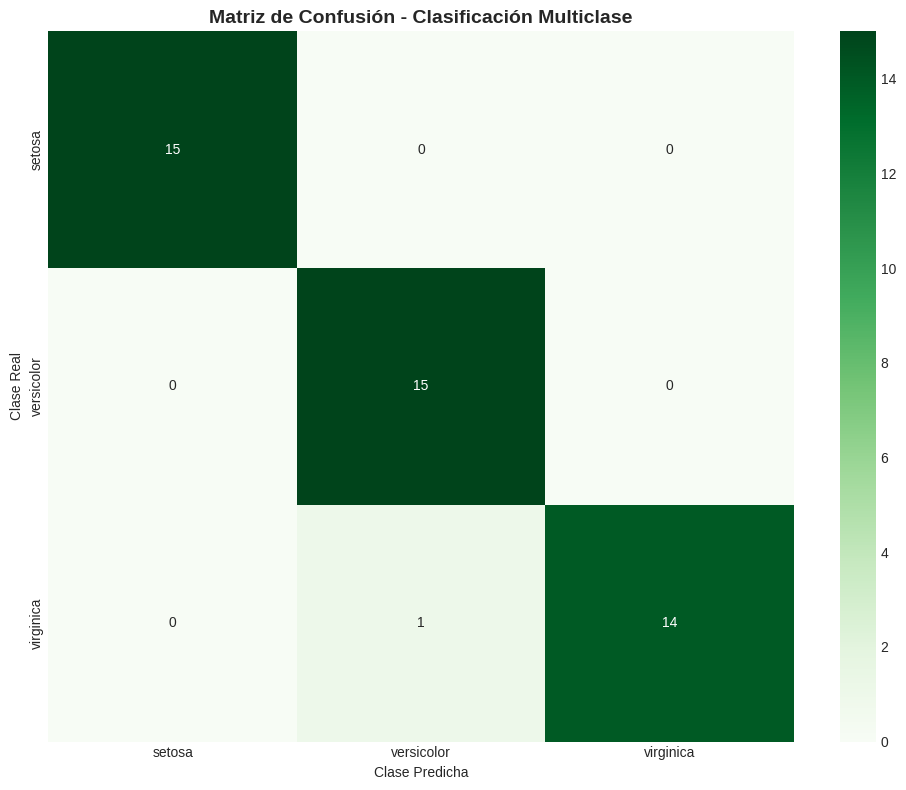

In [ ]:
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Clasificación Multiclase', fontsize=14, fontweight='bold')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()

### 2.2 Métricas para Multiclase
En problemas multiclase, las métricas pueden calcularse de diferentes formas:

**Macro Average**: Promedio simple de las métricas de cada clase (trata todas las clases por igual)
**Weighted Average**: Promedio ponderado por el número de muestras de cada clase
**Micro Average**: Calcula métricas globalmente contando todos los TP, FP, FN

In [ ]:
# Calcular métricas con diferentes promedios
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
precision_macro = precision_score(y_test_multi, y_pred_multi, average='macro')
precision_weighted = precision_score(y_test_multi, y_pred_multi, average='weighted')
recall_macro = recall_score(y_test_multi, y_pred_multi, average='macro')
recall_weighted = recall_score(y_test_multi, y_pred_multi, average='weighted')
f1_macro = f1_score(y_test_multi, y_pred_multi, average='macro')
f1_weighted = f1_score(y_test_multi, y_pred_multi, average='weighted')

print("\n" + "="*70)
print("MÉTRICAS DE EVALUACIÓN - CLASIFICACIÓN MULTICLASE")
print("="*70)
print(f"Accuracy:           {accuracy_multi:.4f} ({accuracy_multi*100:.2f}%)")
print(f"\nPrecision (Macro):  {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"\nRecall (Macro):     {recall_macro:.4f}")
print(f"Recall (Weighted):  {recall_weighted:.4f}")
print(f"\nF1-Score (Macro):   {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

# Reporte de clasificación completo
print("\n" + "="*70)
print("REPORTE DE CLASIFICACIÓN COMPLETO")
print("="*70)
print(classification_report(y_test_multi, y_pred_multi, target_names=iris.target_names))


MÉTRICAS DE EVALUACIÓN - CLASIFICACIÓN MULTICLASE
Accuracy:           0.9778 (97.78%)

Precision (Macro):  0.9792
Precision (Weighted): 0.9792

Recall (Macro):     0.9778
Recall (Weighted):  0.9778

F1-Score (Macro):   0.9778
F1-Score (Weighted): 0.9778

REPORTE DE CLASIFICACIÓN COMPLETO
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



### 2.3 Métricas por Clase Individual


MÉTRICAS POR CLASE
     Clase  Precision   Recall  F1-Score
    setosa     1.0000 1.000000  1.000000
versicolor     0.9375 1.000000  0.967742
 virginica     1.0000 0.933333  0.965517


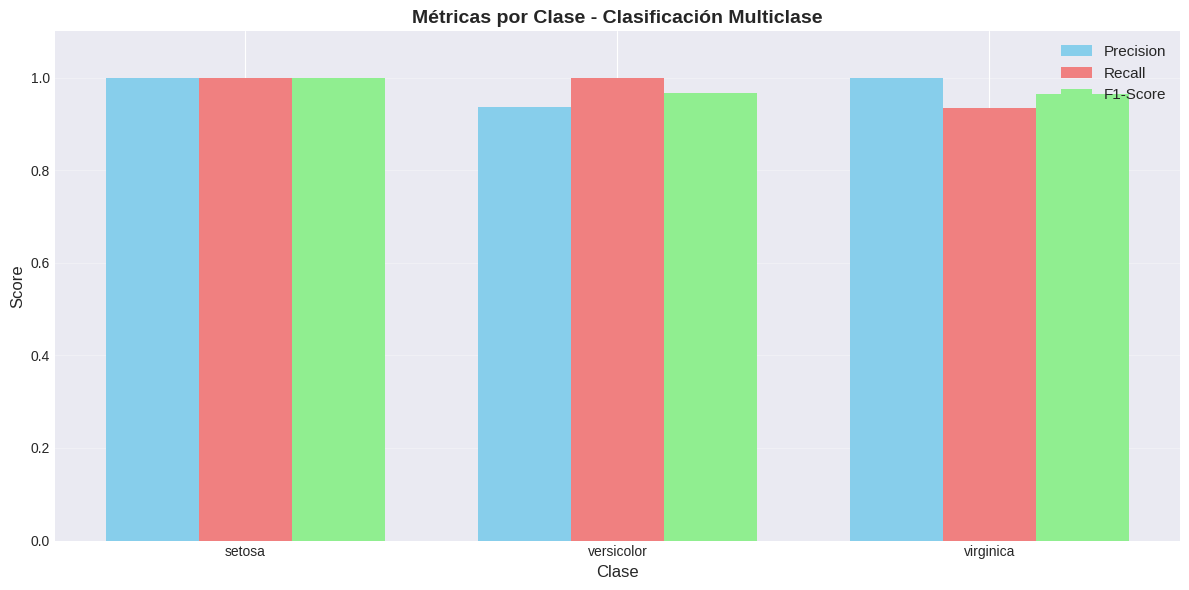

In [ ]:
# Calcular métricas para cada clase
precision_per_class = precision_score(y_test_multi, y_pred_multi, average=None)
recall_per_class = recall_score(y_test_multi, y_pred_multi, average=None)
f1_per_class = f1_score(y_test_multi, y_pred_multi, average=None)

# Visualizar métricas por clase
metrics_df = pd.DataFrame({
    'Clase': iris.target_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
})

print("\n" + "="*70)
print("MÉTRICAS POR CLASE")
print("="*70)
print(metrics_df.to_string(index=False))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(iris.target_names))
width = 0.25

ax.bar(x - width, precision_per_class, width, label='Precision', color='skyblue')
ax.bar(x, recall_per_class, width, label='Recall', color='lightcoral')
ax.bar(x + width, f1_per_class, width, label='F1-Score', color='lightgreen')

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Clase', fontsize=12)
ax.set_title('Métricas por Clase - Clasificación Multiclase', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(iris.target_names)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.3 Curva ROC y AUC

**ROC (Receiver Operating Characteristic)**: Muestra el balance entre True Positive Rate y False Positive Rate
**AUC (Area Under Curve)**: Área bajo la curva ROC. Valores cercanos a 1 indican mejor rendimiento

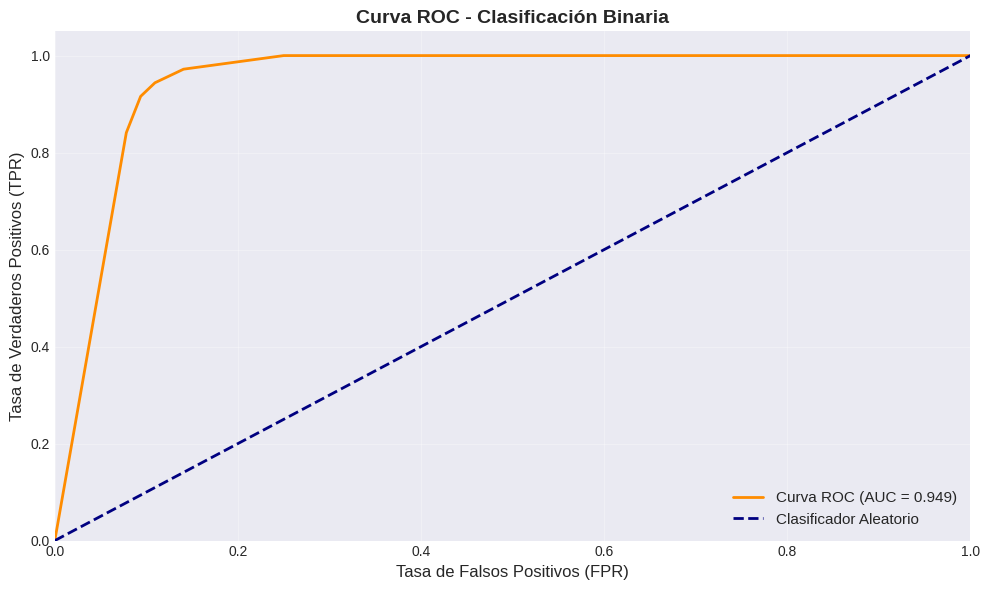


AUC-ROC Score: 0.9489


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_proba_bin)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Clasificación Binaria', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC Score: {roc_auc:.4f}")

### 1.4 Curva Precision-Recall

Útil para datasets desbalanceados. Muestra el trade-off entre precision y recall

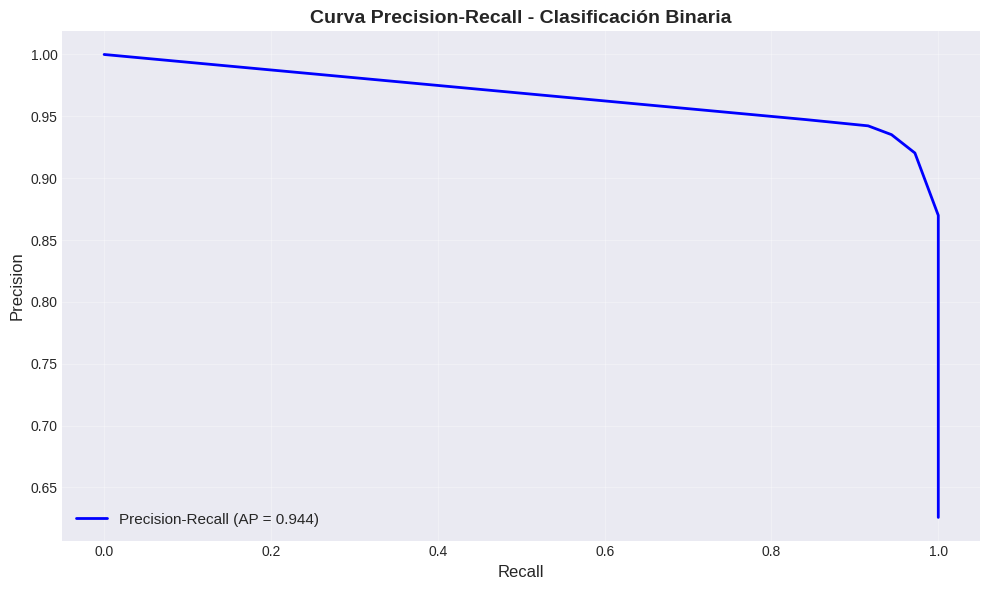

Average Precision Score: 0.9437


In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin, y_pred_proba_bin)
avg_precision = average_precision_score(y_test_bin, y_pred_proba_bin)

plt.figure(figsize=(10, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2,
         label=f'Precision-Recall (AP = {avg_precision:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curva Precision-Recall - Clasificación Binaria', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")